In [40]:
test_df = pd.read_excel(r'C:\Users\mvm\open3d_vision\data\test_shapes.xlsx')

In [36]:
test_df.head()

,X,Y,Layer,PaperSpace,SubClasses,Linetype,EntityHandle,Text
0,118.250000,94.250000,Ground,NaN,AcDbEntity:AcDbLine,CONTINUOUS,4F,NaN
1,124.500000,85.250000,Walls,NaN,AcDbEntity:AcDbLine,CONTINUOUS,50,NaN
2,87.000000,95.125000,0,NaN,AcDbEntity:AcDbPolyline,ByLayer,51,NaN
3,121.935804,83.300721,0,NaN,AcDbEntity:AcDbPolyline,ByLayer,52,NaN
4,90.699500,89.750000,Ground,NaN,AcDbEntity:AcDbCircle,ByLayer,53,NaN


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_excel(r'C:\Users\mvm\open3d_vision\data\building_floor_example_dwg.xlsx')


In [4]:
new_df = pd.read_excel(r'C:\Users\mvm\open3d_vision\data\25-GO1837-CAD-1 ind A.xlsx')

In [5]:
new_df.head()

,X,Y,Z,Layer,PaperSpace,SubClasses,Linetype,EntityHandle,Text
0,87925.778816,101493.073077,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F8B,NaN
1,87917.301822,101442.312655,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F8D,NaN
2,87924.184145,101444.848740,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F8E,NaN
3,87931.032306,101491.785037,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F8F,NaN
4,87943.755882,101488.645989,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F90,NaN


In [6]:
new_df["Linetype"].unique()


<StringArray>
[nan, 'Continuous', 'Tirets petits', '( Dashed )', 'DGN Style 7',
 'DGN Style 4']
Length: 6, dtype: str

In [7]:
new_df["Layer"].unique()

<StringArray>
[     'LIMITE PARCELLAIRE',                  'PORTES',
                   'TEXTE',               'TERRASSES',
                'CLOISONS',             'MUR PORTEUR',
                'FENETRES',               'EXTERIEUR',
                 'PARKING',             'SURFACE-LOT',
               'ESCALIERS',               'TEXTE-LOT',
        'TEXTE-LOT-NUMERO',       'TEXTE-LOT-SURFACE',
                'COTATION',               'Defpoints',
                   'COUPE',           'COTATIONS MUR',
 'CADRE-CARTOUCHE @ 1 (1)', 'CADRE-CARTOUCHE @ 1 (2)',
         'CADRE-CARTOUCHE',                'HACHURES']
Length: 22, dtype: str

In [8]:
def filter_outliers_iqr(df, cols, factor=1.5):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        mask &= df[col].between(lower, upper)
    return df[mask]


def get_layer_colors(layers, cmap_name='tab20'):
    """Return a dict mapping each layer name to a color (for color-by-layer plots)."""
    import matplotlib.pyplot as plt
    import matplotlib
    layers = sorted(pd.Series(layers).dropna().unique().tolist())
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    return {layer: cmap(i % cmap.N) for i, layer in enumerate(layers)}



X                            118.25
Y                             94.25
Layer                        Ground
PaperSpace                      NaN
SubClasses      AcDbEntity:AcDbLine
Linetype                 CONTINUOUS
EntityHandle                     4F
Text                            NaN
Name: 0, dtype: object
X                        121.935804
Y                         83.300721
Layer                         Walls
PaperSpace                      NaN
SubClasses      AcDbEntity:AcDbLine
Linetype                 CONTINUOUS
EntityHandle                     56
Text                            NaN
Name: 7, dtype: object


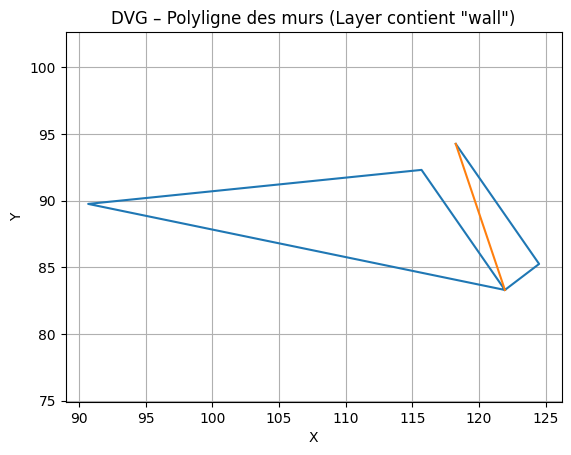

In [ ]:
import matplotlib.pyplot as plt
concat_df = pd.DataFrame()
# Colonnes requises
required_columns = {'Layer', 'EntityHandle', 'X', 'Y'}
if not required_columns.issubset(test_df.columns):
    missing_columns = required_columns - set(test_df.columns)
    raise ValueError(f"Colonnes manquantes : {missing_columns}")


# Vérifier qu'il y a des points valides
test_df = test_df.dropna(subset=['X', 'Y'])

test_df = filter_outliers_iqr(test_df, ['X', 'Y'])
# Création du plot
# plt.figure(figsize=(40, 20))

# Tracer une seule polyligne avec tous les points
plt.plot(
    test_df['X'],
    test_df['Y'],

)

# Fermer la polyligne (relier premier et dernier point)
if len(new_df) > 1:
    first_point = test_df.iloc[0]
    last_point = test_df.iloc[-1]
    print(first_point)
    print(last_point)
    plt.plot(
        [first_point['X'], last_point['X']],
        [first_point['Y'], last_point['Y']],
      
    )

# Paramètres du graphique
plt.xlabel('X')
plt.ylabel('Y')
plt.title('DVG – Polyligne des murs (Layer contient "wall")')
plt.axis('equal')
plt.grid(True)

plt.show()


In [19]:
new_df.head()

,X,Y,Z,Layer,PaperSpace,SubClasses,Linetype,EntityHandle,Text
0,87925.778816,101493.073077,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F8B,NaN
1,87917.301822,101442.312655,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F8D,NaN
2,87924.184145,101444.848740,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F8E,NaN
3,87931.032306,101491.785037,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F8F,NaN
4,87943.755882,101488.645989,0,LIMITE PARCELLAIRE,NaN,AcDbEntity:AcDbLine,NaN,14F90,NaN


In [ ]:
"""
promt for ChatGPT:

+ now get from each polyline only one "ParentID" - find this id in column "ID" take value "Area" divide by 1000000 and add this value on plot

"""

######################### ChatGPT Answer #########################

# Check if 'Area' column exists in the dataframe
if 'Area' not in concat_df.columns:
    raise ValueError("Missing required column: 'Area'")

# Build layer colors if 'Layer' exists in the grouped dataframe
layer_colors = {}
if 'Layer' in elements_with_matching_parent_ids.columns:
    layer_colors = get_layer_colors(elements_with_matching_parent_ids['Layer'])

# Updating the plot with the new requirements
plt.figure(figsize=(40, 20))

# Iterate over each group and plot (color by layer when available)
for parent_id, group in elements_with_matching_parent_ids.groupby('ParentID'):
    # Check if there are any non-empty 'Point' values in the group
    if group['Point'].dropna().empty:
        continue  # Skip this group if 'Point' column is empty
    layer_name = group['Layer'].iloc[0] if 'Layer' in group.columns else None
    color = layer_colors.get(layer_name, 'gray') if layer_name is not None else 'gray'
    split_points = clean_and_split_points(group['Point'].dropna())
    plt.plot(split_points['x'], split_points['y'], marker='o', color=color, label=layer_name if layer_name and layer_name not in [l for l in plt.gca().get_legend_handles_labels()[1]] else None)  # Draw the polyline

    # Connect the first and last points if available
    if len(split_points) > 0:
        first_point = split_points.iloc[0]
        last_point = split_points.iloc[-1]
        plt.plot([first_point['x'], last_point['x']], [first_point['y'], last_point['y']], color=color, linestyle='-', marker='o')

        # Find the 'Area' for this 'ParentID', divide by 1000000, and annotate on the plot
        area_value = df[df['ID'] == parent_id]['Area'].iloc[0] / 1000000
        mid_point = split_points.mean()  # A point to place the annotation
        plt.annotate(f"{area_value:.2f}", (mid_point['x'], mid_point['y']), textcoords="offset points", xytext=(0,10), ha='center')

# Avoid duplicate legend labels: build legend from unique layers
if layer_colors:
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=layer_colors[l], lw=2, label=l) for l in sorted(layer_colors)]
    plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left')

# Final plot settings
plt.xlabel('X Koordinate')
plt.ylabel('Y Koordinate')
plt.title('Separate Polylinien nach ParentID mit verbundenem ersten und letzten Punkt und Flächenangaben (Farben nach Layer)')
plt.axis('equal')  # Set equal scaling on x and y axes
plt.show()